In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [4]:

PROJECT_ROOT = Path.cwd().parents[0]
DATA_DIR = PROJECT_ROOT / "data" / "raw"

career_df = pd.read_csv(DATA_DIR / "Career_Stats_Receiving.csv")
wr_df = pd.read_csv(DATA_DIR / "Game_Logs_Wide_Receiver_and_Tight_End.csv")

In [5]:
print("Career Receiving Stats:")
print(career_df.head(10))
print("\nWR/TE Game Logs:")
print(wr_df.head(10))

Career Receiving Stats:
             Player Id            Name Position  Year                Team  \
0    fredevans/2513736     Evans, Fred      NaN  1948       Chicago Bears   
1    fredevans/2513736     Evans, Fred      NaN  1948     Chicago Rockets   
2    fredevans/2513736     Evans, Fred      NaN  1947     Chicago Rockets   
3    fredevans/2513736     Evans, Fred      NaN  1947       Buffalo Bills   
4    fredevans/2513736     Evans, Fred      NaN  1946    Cleveland Browns   
5  bobbyfowler/2514295   Fowler, Bobby      NaN  1985  New Orleans Saints   
6   quinnjohnson/79593  Johnson, Quinn      NaN  2013    Tennessee Titans   
7   quinnjohnson/79593  Johnson, Quinn      NaN  2012    Tennessee Titans   
8   quinnjohnson/79593  Johnson, Quinn      NaN  2011    Tennessee Titans   
9   quinnjohnson/79593  Johnson, Quinn      NaN  2011      Denver Broncos   

   Games Played Receptions Receiving Yards Yards Per Reception  \
0             3          1              -2                -2.0

In [6]:
print("\nCareer Stats Shape:", career_df.shape)
print("Game Logs Shape:", wr_df.shape)

print("\nNulls in Career Stats:\n", career_df.isnull().sum())
print("\nNulls in Game Logs:\n", wr_df.isnull().sum())


Career Stats Shape: (18128, 16)
Game Logs Shape: (112632, 25)

Nulls in Career Stats:
 Player Id                              0
Name                                   0
Position                           15728
Year                                   0
Team                                   0
Games Played                           0
Receptions                             0
Receiving Yards                        0
Yards Per Reception                    0
Yards Per Game                         0
Longest Reception                      0
Receiving TDs                          0
Receptions Longer than 20 Yards        0
Receptions Longer than 40 Yards        0
First Down Receptions                  0
Fumbles                                0
dtype: int64

Nulls in Game Logs:
 Player Id                  0
Name                       0
Position               87846
Year                       0
Season                     0
Week                       0
Game Date                  0
Home or Away      

In [7]:
# --- Filter and Clean the Data (1980 onward) ---

# Convert 'Year' to numeric, in case it's stored as string or has bad data
career_df['Year'] = pd.to_numeric(career_df['Year'], errors='coerce')
wr_df['Year'] = pd.to_numeric(wr_df['Year'], errors='coerce')

# Filter to include only rows from 1980 onward
career_df = career_df[career_df['Year'] >= 1980]
wr_df = wr_df[wr_df['Year'] >= 1980]

# Drop rows with any NaN values
career_df = career_df.dropna()
wr_df = wr_df.dropna()

# Check resulting shapes
print("Filtered Career Stats shape:", career_df.shape)
print("Filtered Game Logs shape:", wr_df.shape)


Filtered Career Stats shape: (2400, 16)
Filtered Game Logs shape: (24786, 25)


In [10]:
# Convert relevant columns to numeric in case of bad strings or '--'
wr_df["Receiving Yards"] = pd.to_numeric(wr_df["Receiving Yards"], errors="coerce")
wr_df["Receiving TDs"] = pd.to_numeric(wr_df["Receiving TDs"], errors="coerce")

# Optional: include rushing if present
wr_df["Rushing Yards"] = pd.to_numeric(wr_df.get("Rushing Yards", 0), errors="coerce")
wr_df["Rushing TDs"] = pd.to_numeric(wr_df.get("Rushing TDs", 0), errors="coerce")

# Fill NaNs (if any) after coercion
wr_df.fillna(0, inplace=True)

wr_df


,Player Id,Name,Position,Year,Season,Week,Game Date,Home or Away,Opponent,Outcome,...,Rushing Attempts,Rushing Yards,Yards Per Carry,Longest Rushing Run,Rushing TDs,Fumbles,Fumbles Lost,Total_Yards,Total_TDs,WR_Value_Score
677,kevinnorwood/2543689,"Norwood, Kevin",WR,2016,Preseason,1,08/11,Away,BAL,L,...,--,0.0,--,--,0.0,--,--,13.0,0.0,13.0
678,kevinnorwood/2543689,"Norwood, Kevin",WR,2016,Preseason,2,08/20,Away,TEN,W,...,--,0.0,--,--,0.0,--,--,31.0,1.0,81.0
679,kevinnorwood/2543689,"Norwood, Kevin",WR,2016,Preseason,3,08/26,Home,NE,L,...,--,0.0,--,--,0.0,--,--,-2.0,0.0,-2.0
680,kevinnorwood/2543689,"Norwood, Kevin",WR,2016,Preseason,4,09/01,Home,PIT,W,...,--,0.0,--,--,0.0,--,--,17.0,0.0,17.0
681,kevinnorwood/2543689,"Norwood, Kevin",WR,2015,Preseason,1,08/14,Home,DEN,L,...,--,0.0,--,--,0.0,--,--,7.0,0.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112624,torreysmith/2495459,"Smith, Torrey",WR,2011,Regular Season,15,12/18,Away,SD,L,...,--,0.0,--,--,0.0,1,0,77.0,1.0,127.0
112625,torreysmith/2495459,"Smith, Torrey",WR,2011,Regular Season,16,12/24,Home,CLE,W,...,--,0.0,--,--,0.0,--,--,38.0,0.0,38.0
112626,torreysmith/2495459,"Smith, Torrey",WR,2011,Regular Season,17,01/01,Away,CIN,W,...,--,0.0,--,--,0.0,--,--,33.0,0.0,33.0
112627,torreysmith/2495459,"Smith, Torrey",WR,2011,Postseason,19,01/15,Home,HOU,W,...,--,0.0,--,--,0.0,--,--,9.0,0.0,9.0


In [11]:
# Compute new features
wr_df["Total_Yards"] = wr_df["Receiving Yards"] + wr_df["Rushing Yards"]
wr_df["Total_TDs"] = wr_df["Receiving TDs"] + wr_df["Rushing TDs"]

# Create a value score (similar to RB): Tune weight (e.g., 50) if needed
wr_df["WR_Value_Score"] = wr_df["Total_Yards"] + wr_df["Total_TDs"] * 50

# Preview
wr_df[["Player Id", "Name", "Year", "Total_Yards", "Total_TDs", "WR_Value_Score"]].head()


,Player Id,Name,Year,Total_Yards,Total_TDs,WR_Value_Score
677,kevinnorwood/2543689,"Norwood, Kevin",2016,13.0,0.0,13.0
678,kevinnorwood/2543689,"Norwood, Kevin",2016,31.0,1.0,81.0
679,kevinnorwood/2543689,"Norwood, Kevin",2016,-2.0,0.0,-2.0
680,kevinnorwood/2543689,"Norwood, Kevin",2016,17.0,0.0,17.0
681,kevinnorwood/2543689,"Norwood, Kevin",2015,7.0,0.0,7.0


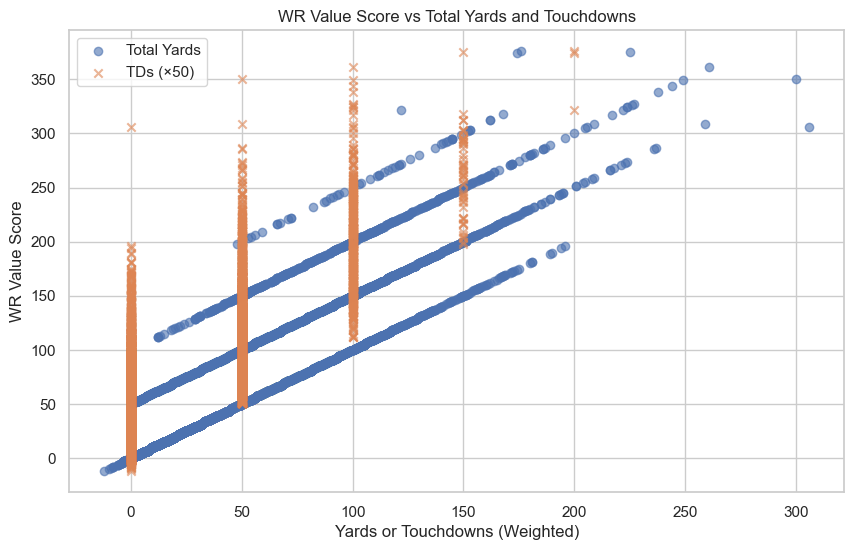

In [12]:
# --- Scatter Plot: WR Value Score vs Total Yards & TDs ---

plt.figure(figsize=(10, 6))
plt.scatter(wr_df["Total_Yards"], wr_df["WR_Value_Score"], alpha=0.6, label="Total Yards")
plt.scatter(wr_df["Total_TDs"] * 50, wr_df["WR_Value_Score"], alpha=0.6, label="TDs (×50)", marker="x")

plt.xlabel("Yards or Touchdowns (Weighted)")
plt.ylabel("WR Value Score")
plt.title("WR Value Score vs Total Yards and Touchdowns")
plt.legend()
plt.grid(True)
plt.show()


### WR Value Score vs Total Yards and Touchdowns

This scatter plot visualizes the relationship between a wide receiver's **Value Score** and two key performance metrics:

- **Total Yards** (Receiving + Rushing): represented by **blue circles**
- **Total Touchdowns** (Receiving + Rushing): represented by **orange X's**, scaled by ×50 to align with yardage impact

#### Key Observations:
- Each **blue dot** corresponds to a player's yardage contribution for a game and its associated value score.
- Each **orange X** shows how touchdowns alone correlate with the value score after applying a scaling factor of 50.
- The **diagonal clustering patterns** suggest a linear relationship: value increases consistently with either more yards or more touchdowns.
- Touchdowns are fewer and more discrete (e.g., 0, 1, 2...) — hence, we see **vertical groupings** in orange points.

#### Why Scale TDs by 50?
Touchdowns have a much larger impact on game outcomes and fantasy/reward models compared to yards. The factor of 50 was chosen to bring TDs into the same numeric range as yards, allowing visual comparison in the same plot space. This factor can be tuned based on regression coefficients or further optimization.



______________________________________________________________________________________________________________________________________________________
Modeling Plan (Stages 4–5 for WR):

Features (X):

Receptions

Receiving Yards + Rushing Yards → combined into Total_Yards

Total_TDs = Receiving TDs + Rushing TDs

Fumbles (as negative input)

Target (y):

WR_Value_Score (already calculated earlier)

Model Type:

Start with Linear Regression for interpretability.

Later try Ridge, Lasso, or Logistic if binning into performance tiers.

In [13]:
# Linear Regression Model for WR Value Score
# Prepare features and target
features = ["Receptions", "Total_Yards", "Total_TDs", "Fumbles"]
X = wr_df[features]
y = wr_df["WR_Value_Score"]

# Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fit Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("🔢 Linear Regression Coefficients:")
for feat, coef in zip(features, model.coef_):
    print(f"  {feat}: {coef:.2f}")
print(f"\nR² Score: {r2:.3f}")
print(f"Mean Squared Error: {mse:.1f}")

ValueError: could not convert string to float: '--'